In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tifffile as tiff
from skimage.transform import resize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Add, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings("ignore")

2026-01-18 10:44:42.921719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768733083.394943      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768733083.543769      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768733084.656335      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768733084.656368      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768733084.656371      24 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SIZE = (64, 64)
NUM_CLASSES = 10

CLASSES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

SPECTRAL_BANDS = [
    'Coastal Aerosol', 'Blue', 'Green', 'Red', 'Red Edge 1',
    'Red Edge 2', 'Red Edge 3', 'NIR', 'Red Edge 4',
    'Water Vapor', 'SWIR Cirrus', 'SWIR 1', 'SWIR 2'
]


In [3]:
DATASET_PATH = "/kaggle/input/eurosat-dataset/EuroSATallBands"


In [4]:
def load_satellite_data(dataset_dir, img_size=IMG_SIZE):
    data = []
    labels = []
    for class_name in sorted(os.listdir(dataset_dir)):
        class_path = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file_name in os.listdir(class_path):
            img_path = os.path.join(class_path, file_name)
            try:
                img = tiff.imread(img_path)
                if img.shape[-1] != 13:
                    continue
                img = resize(img, (img_size[0], img_size[1], 13),
                             preserve_range=True, anti_aliasing=True)
                img = img.astype(np.float32)
                img /= img.max()
                data.append(img)
                labels.append(class_name)
            except:
                pass
    return np.array(data), np.array(labels)


In [5]:
X, Y = load_satellite_data(DATASET_PATH)
X.shape, Y.shape


((27597, 64, 64, 13), (27597,))

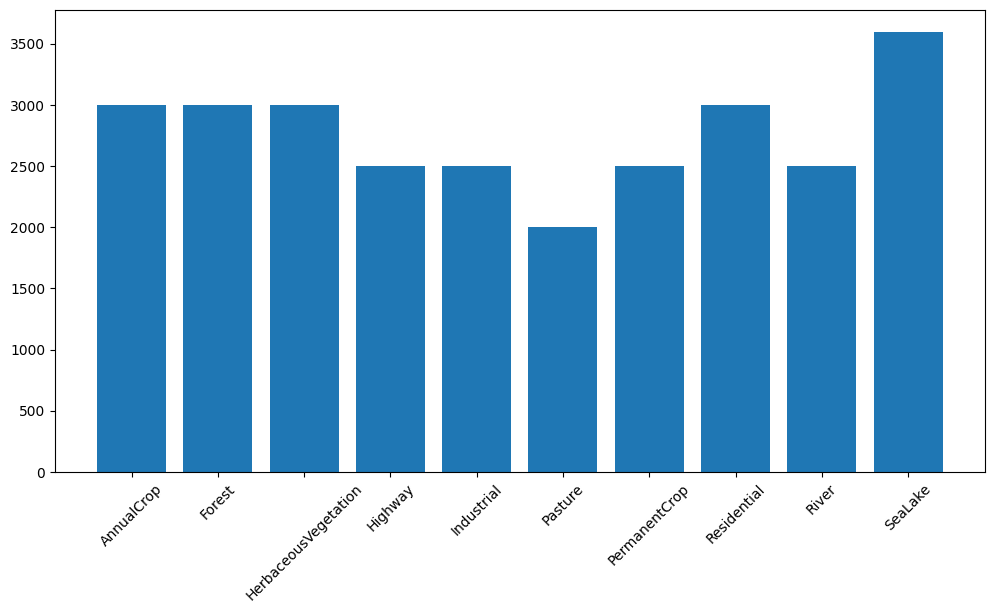

In [6]:
unique, counts = np.unique(Y, return_counts=True)
plt.figure(figsize=(12,6))
plt.bar(unique, counts)
plt.xticks(rotation=45)
plt.show()


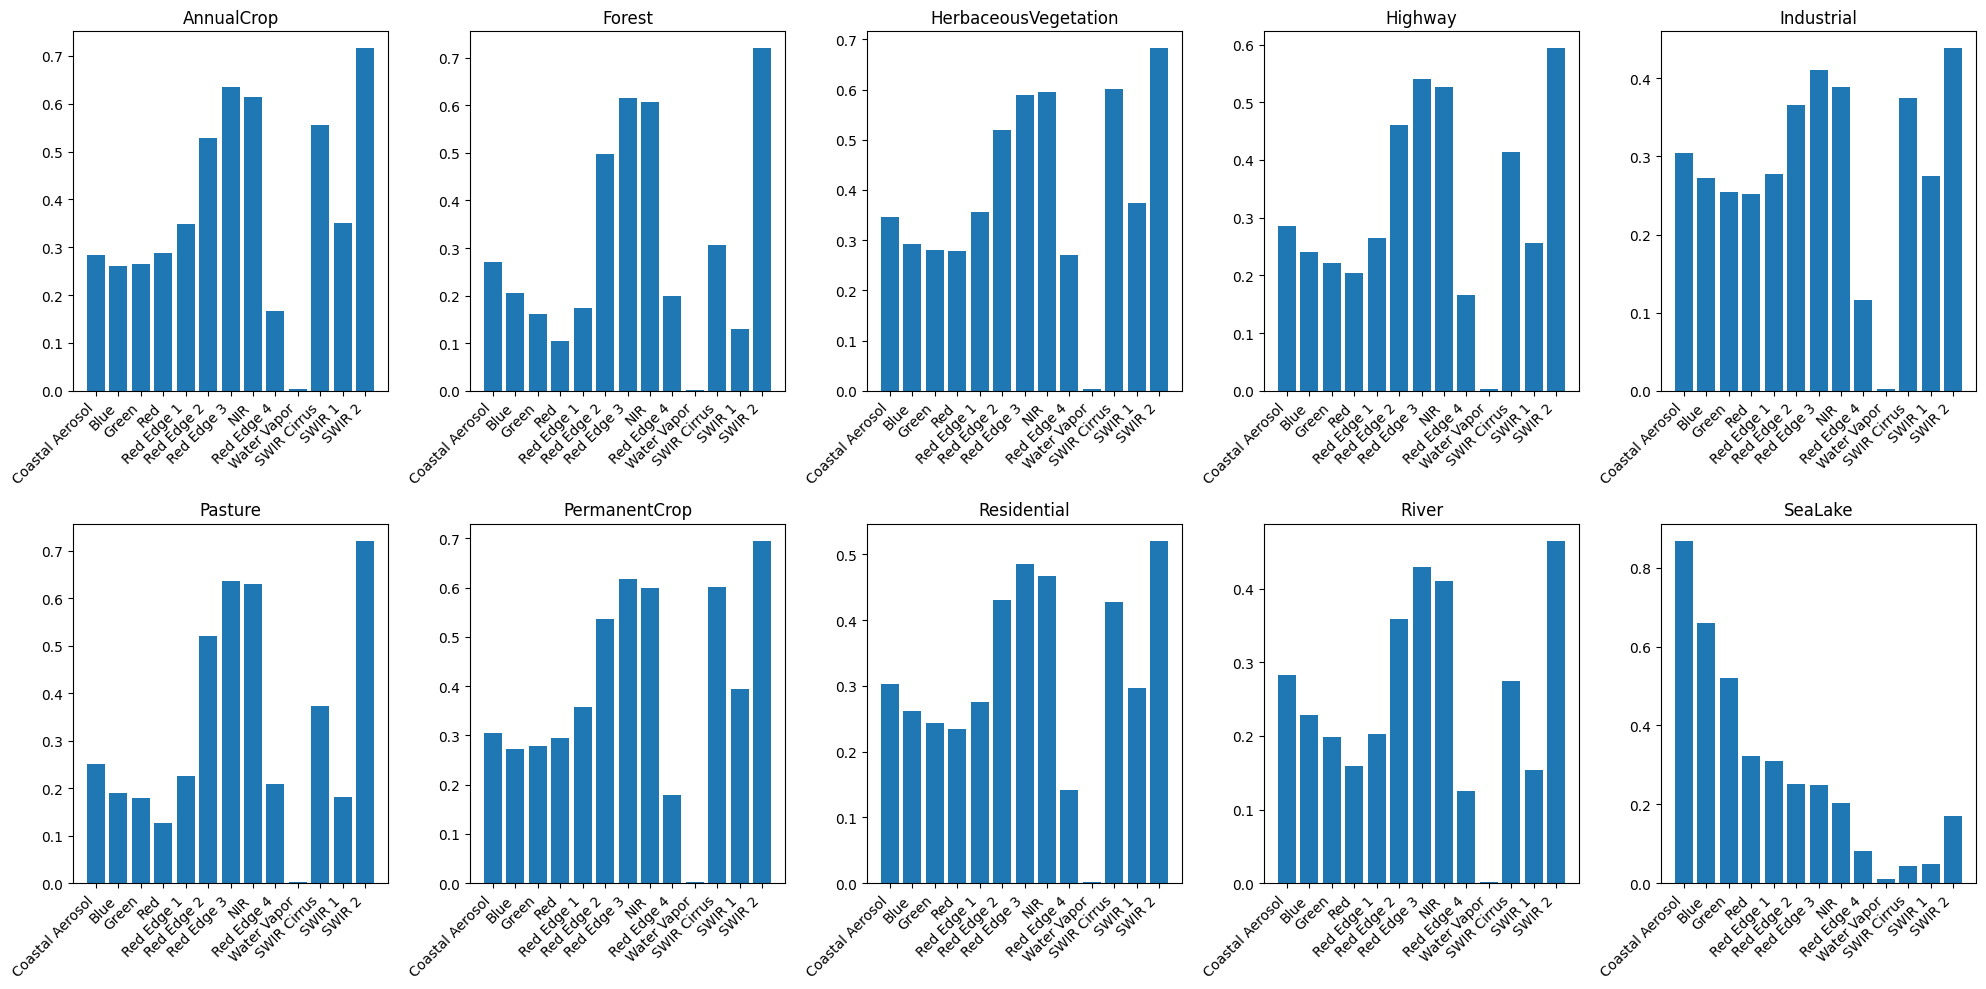

In [7]:
def plot_spectral_bands(data, labels):
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.ravel()
    for i, class_name in enumerate(CLASSES):
        idx = np.where(labels == class_name)[0]
        mean_spec = np.mean(data[idx], axis=(0,1,2))
        axes[i].bar(range(len(SPECTRAL_BANDS)), mean_spec)
        axes[i].set_xticks(range(len(SPECTRAL_BANDS)))
        axes[i].set_xticklabels(SPECTRAL_BANDS, rotation=45, ha='right')
        axes[i].set_title(class_name)
    plt.tight_layout()
    plt.show()

plot_spectral_bands(X, Y)


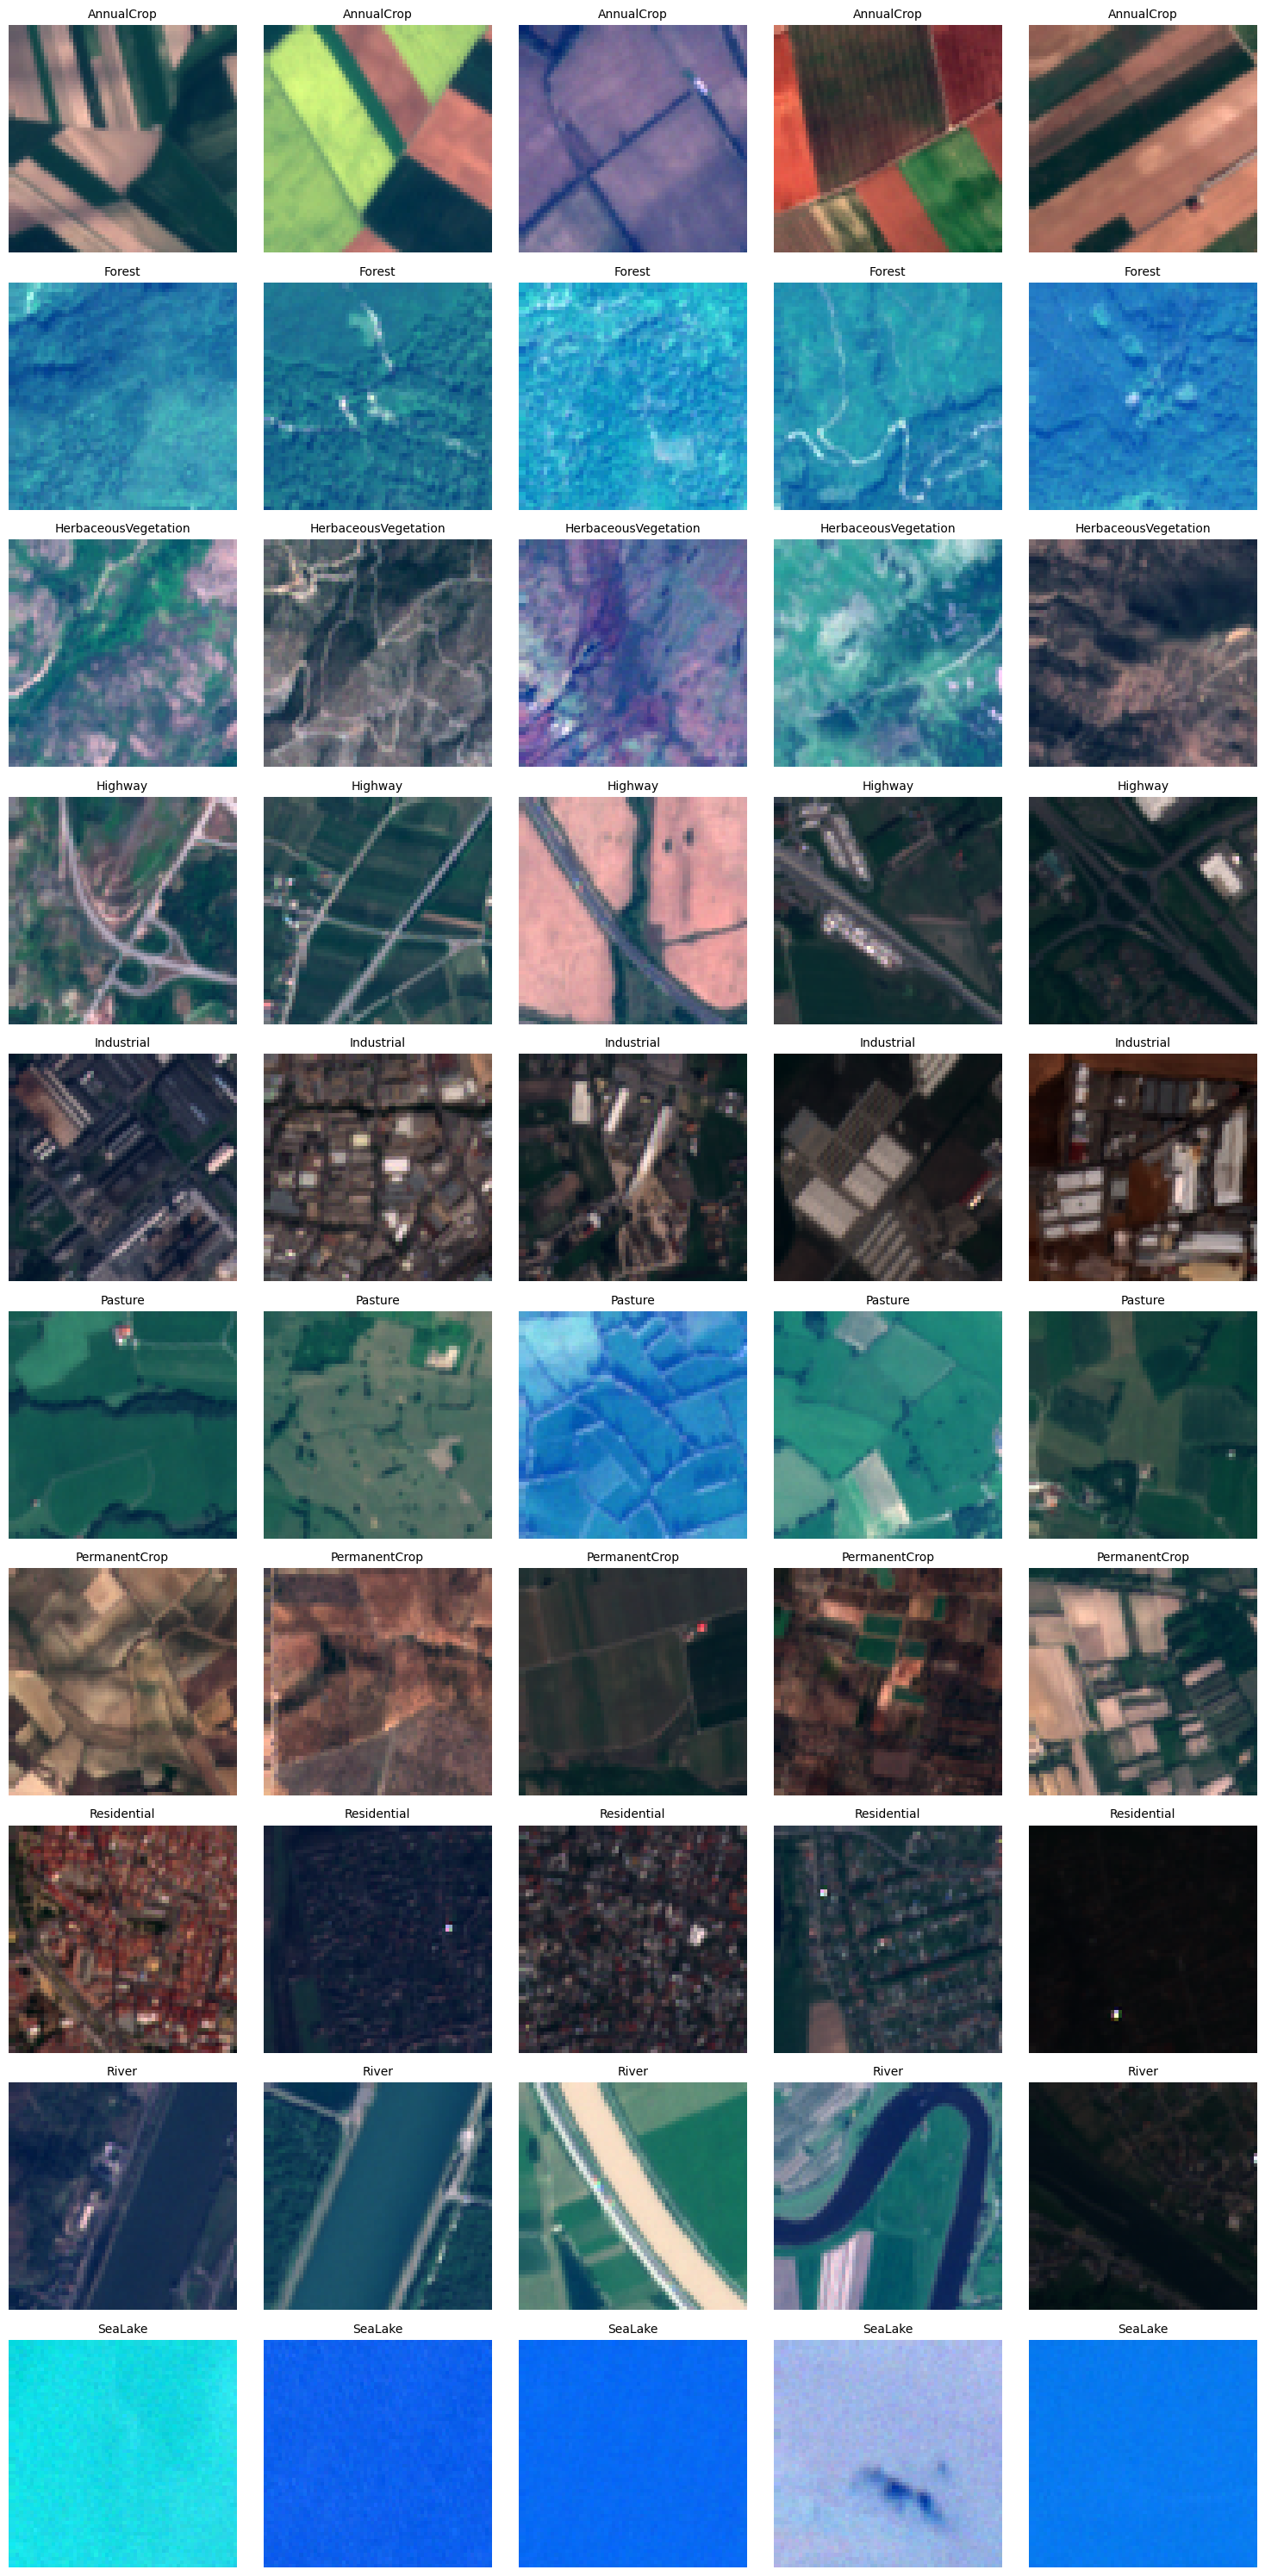

In [8]:
def plot_sample_images(data, labels, classes, n=5):
    rgb_idx = [3,2,1]  # assuming RGB channels
    fig, axes = plt.subplots(len(classes), n, figsize=(3*n, 3*len(classes)))

    for i, cls in enumerate(classes):
        idx = np.where(labels == cls)[0][:n]
        for j, k in enumerate(idx):
            img = data[k][:,:,rgb_idx]
            img = (img - img.min()) / (img.max() - img.min())
            axes[i,j].imshow(img)
            axes[i,j].axis("off")
            axes[i,j].set_title(cls, fontsize=10)  # class name on top

    plt.tight_layout()
    plt.show()

# Usage
plot_sample_images(X, Y, CLASSES, n=5)

In [9]:
le = LabelEncoder()
y_enc = le.fit_transform(Y)
Y_onehot = to_categorical(y_enc, NUM_CLASSES)

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y_onehot, test_size=0.2, random_state=42, stratify=Y_onehot
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)


In [10]:
def SpectrumNet_lite(input_shape=(64,64,13), num_classes=10):
    inp = Input(input_shape)
    x = Conv2D(64,(1,1),strides=2,padding="same")(inp)

    def block(x,f):
        sc = x
        x1 = Conv2D(f,(1,1),padding="same")(x)
        x2 = Conv2D(f,(3,3),padding="same")(x)
        x = Concatenate()([x1,x2])
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        if sc.shape[-1] == x.shape[-1]:
            x = Add()([sc,x])
        return x

    x = block(x,32)
    x = MaxPooling2D()(x)
    x = block(x,64)
    x = MaxPooling2D()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128,activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(num_classes,activation="softmax")(x)
    return Model(inp,out)


In [11]:
model = SpectrumNet_lite((64,64,13), NUM_CLASSES)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


I0000 00:00:1768733462.658646      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768733462.662500      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
ckpt = ModelCheckpoint("/kaggle/working/best_model.keras", monitor="val_accuracy", save_best_only=True)
es = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=10,
    callbacks=[ckpt, es],
    verbose=1
)


Epoch 1/40


I0000 00:00:1768733478.152674      72 service.cc:152] XLA service 0x7b092c0351b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768733478.152711      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768733478.152715      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768733478.846405      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


  35/2208 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3037 - loss: 2.1106

I0000 00:00:1768733484.285635      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2208/2208 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.5897 - loss: 1.1703 - val_accuracy: 0.7862 - val_loss: 0.6085
Epoch 2/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7854 - loss: 0.6277 - val_accuracy: 0.8250 - val_loss: 0.4662
Epoch 3/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8313 - loss: 0.4925 - val_accuracy: 0.8848 - val_loss: 0.3241
Epoch 4/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8559 - loss: 0.4192 - val_accuracy: 0.8236 - val_loss: 0.5248
Epoch 5/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8737 - loss: 0.3766 - val_accuracy: 0.9007 - val_loss: 0.2847
Epoch 6/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8854 - loss: 0.3428 - val_accuracy: 0.9163 - val_loss: 0.2456
Epoch 7/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8907 - loss: 0.3227 - val_accuracy: 0.8254 - val_loss: 0.5648
Epoch 8/40
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9070 - loss: 0.2867 - val_accura

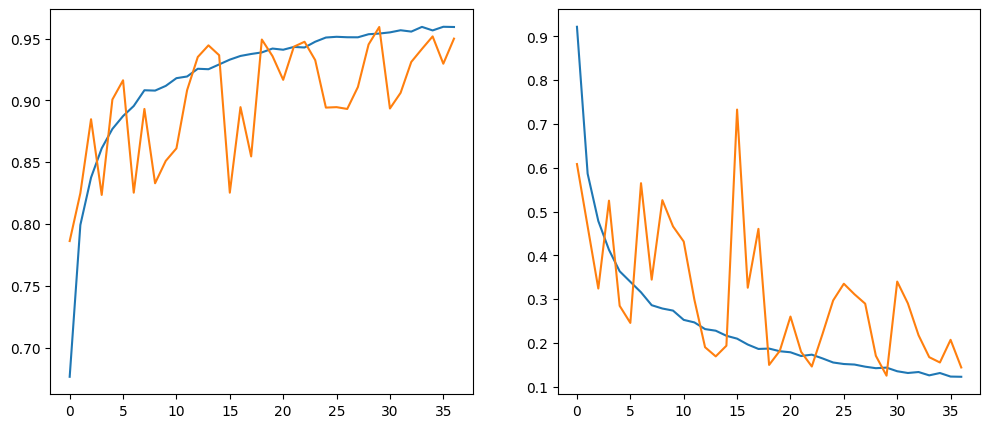

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()


In [14]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
test_acc


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9595 - loss: 0.1421


0.9630434513092041

In [15]:
y_pred = model.predict(X_test)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true = np.argmax(Y_test, axis=1)

print(classification_report(y_true, y_pred_cls, target_names=le.classes_))


87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.98      0.96       300
              Forest       0.98      1.00      0.99       300
HerbaceousVegetation       0.94      0.97      0.96       300
             Highway       0.97      0.85      0.91       250
          Industrial       0.93      0.96      0.94       250
             Pasture       0.93      0.93      0.93       200
       PermanentCrop       0.97      0.96      0.96       250
         Residential       0.98      0.98      0.98       300
               River       0.98      0.96      0.97       250
             SeaLake       0.99      1.00      0.99       360

            accuracy                           0.96      2760
           macro avg       0.96      0.96      0.96      2760
        weighted avg       0.96      0.96      0.96      2760



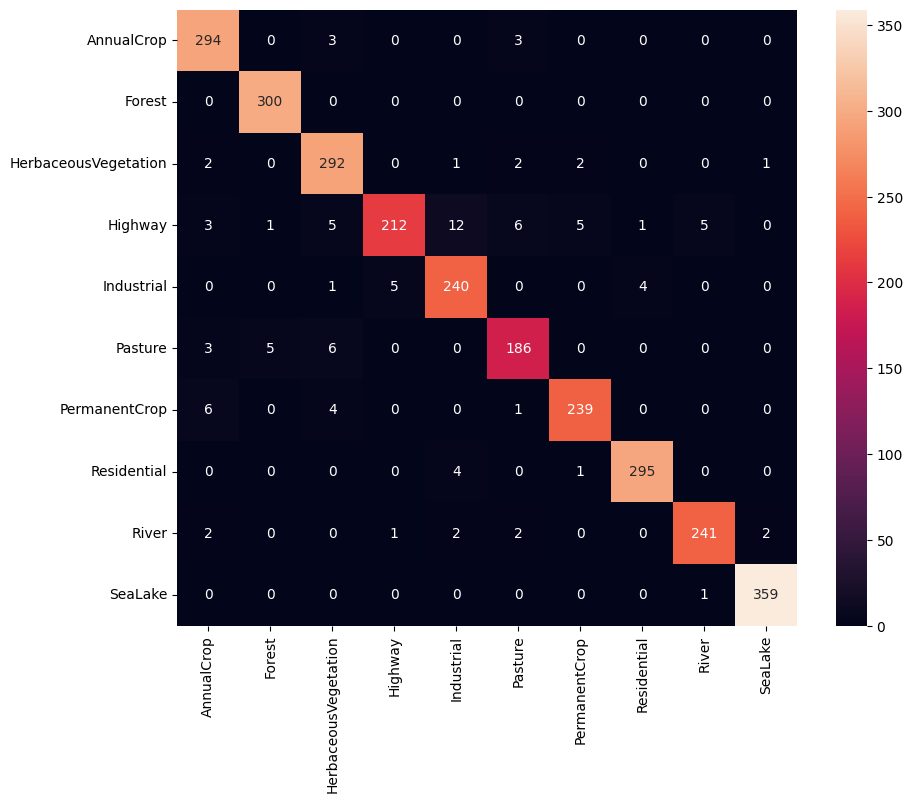

In [16]:
cm = confusion_matrix(y_true, y_pred_cls)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.show()


In [17]:
def grad_cam(model, image, class_idx, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(tf.expand_dims(image,0))
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0,1,2))
    cam = tf.reduce_sum(tf.multiply(weights, conv_out), axis=-1)[0]
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()
    return cam


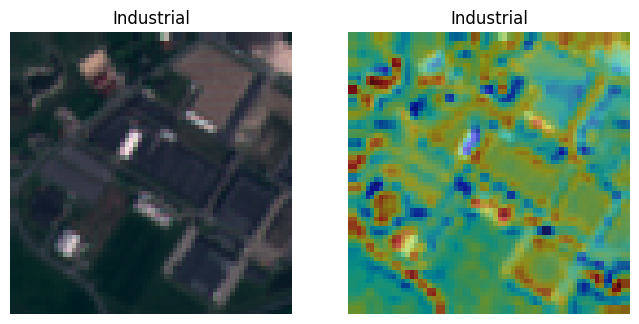

In [18]:
idx = 0
img = X_test[idx]
true_label = le.classes_[y_true[idx]]
pred_label = le.classes_[y_pred_cls[idx]]

cam = grad_cam(model, img, y_pred_cls[idx], "conv2d")
cam = resize(cam, IMG_SIZE)

rgb = img[:,:, [3,2,1]]
rgb = (rgb-rgb.min())/(rgb.max()-rgb.min())

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title(true_label)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(pred_label)
plt.axis("off")
plt.show()


In [19]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from skimage.transform import resize
import numpy as np

def plot_gradcam_examples(model, X, y_true, y_pred, le, n=5, img_size=(128,128)):
    rgb_idx = [3,2,1]
    fig = plt.figure(figsize=(8, 4*n))
    gs = gridspec.GridSpec(n, 2, wspace=0.05, hspace=0.3)  # reduce wspace for smaller gap

    for idx in range(n):
        img = X[idx]
        true_label = le.classes_[y_true[idx]]
        pred_label = le.classes_[y_pred[idx]]

        cam = grad_cam(model, img, y_pred[idx], "conv2d")
        cam = resize(cam, img_size)

        rgb = img[:, :, rgb_idx]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

        # Original Image
        ax = fig.add_subplot(gs[idx, 0])
        ax.imshow(rgb)
        ax.set_title(f"True: {true_label}", fontsize=10)
        ax.axis("off")

        # Image + Grad-CAM
        ax = fig.add_subplot(gs[idx, 1])
        ax.imshow(rgb)
        ax.imshow(cam, cmap="jet", alpha=0.5)
        ax.set_title(f"Pred: {pred_label}", fontsize=10)
        ax.axis("off")

    plt.show()


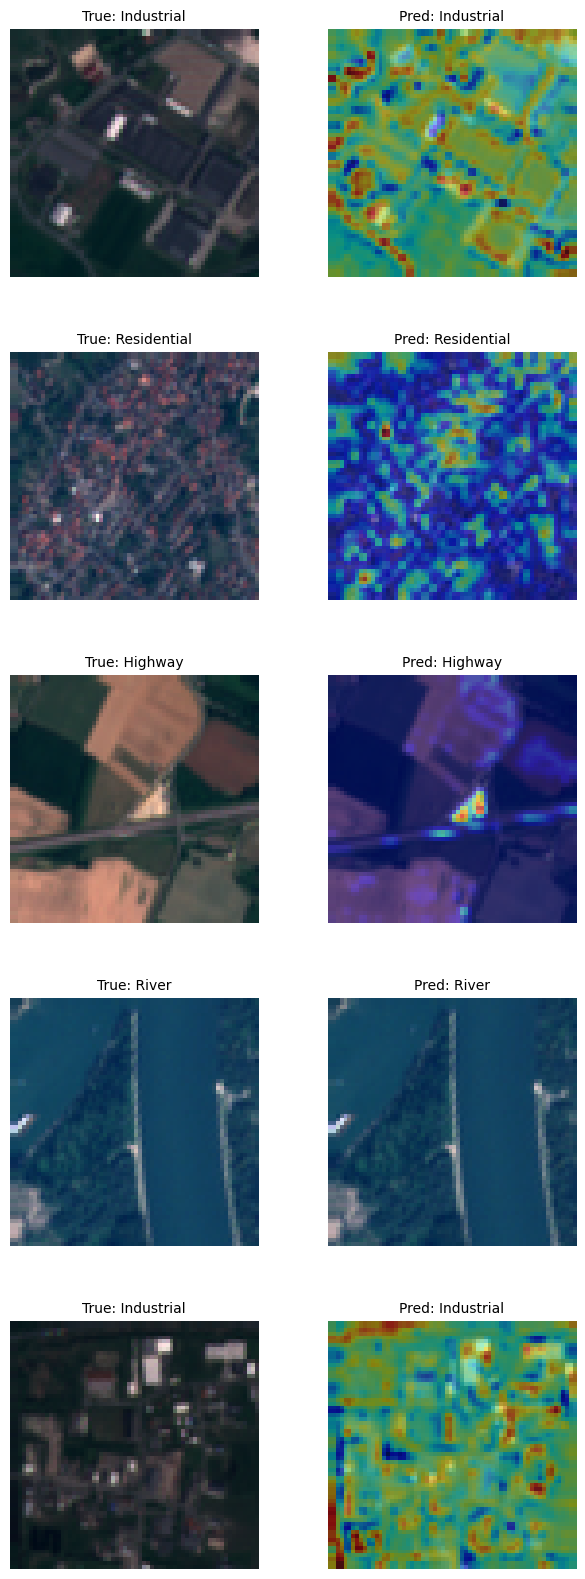

In [20]:

# Usage
plot_gradcam_examples(model, X_test, y_true, y_pred_cls, le, n=5, img_size=IMG_SIZE)